# 第 2 节课 · Notebook 3：CNN 训练 MNIST + 卷积本质

## 本 Notebook 目标

完成本 Notebook 后，你将能够：
1. 解释卷积操作的核心思想：局部连接、权值共享
2. 用手写代码（Unfold + MatMul）验证卷积和 PyTorch 官方实现等价
3. 用 PyTorch 搭建并训练一个 CNN，在 MNIST 上 3 个 epoch 达到 98%+
4. 计算并对比 CNN 和 MLP 的参数量
5. 可视化卷积核和特征图，理解 CNN 自动学习到的特征
6. 解释为什么 CNN 比 MLP 更适合图像任务

## 为什么需要 CNN？

上一节我们用 MLP 在 MNIST 上达到了 95%+ 的准确率。但 MLP 有一个根本问题：

> 它把 28×28 的图片展平成 784 维向量，完全忽略了像素之间的空间关系。

真实图像具有很强的局部相关性：
- 相邻像素往往属于同一个物体
- 边缘、纹理等低级特征是局部出现的
- 同一个特征（如一条竖线）可能出现在图片的任何位置

**卷积神经网络（Convolutional Neural Network, CNN）** 的设计正是利用了这些先验知识：
- **局部连接**：每个神经元只连接输入的一个局部区域
- **权值共享**：同一个卷积核在整张图片上滑动使用
- **池化**：降低特征图尺寸，减少计算量，增加平移不变性


## 0. 环境准备


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 自动选择设备
device = torch.device('cuda' if torch.cuda.is_available() else
                     'mps' if torch.backends.mps.is_available() else
                     'cpu')
print(f"使用设备: {device}")


使用设备: cuda


## 1. 卷积的数学本质

### 1.1 什么是卷积？

在深度学习中，**二维卷积**的操作是：

用一个小的矩阵（称为**卷积核**或**滤波器**）在输入图片上滑动，每到一个位置就做点乘，得到一个输出值。

如果输入是单通道图片 $X$，卷积核是 $K$，那么输出特征图 $Y$ 在位置 $(i, j)$ 的值为：

$$Y[i, j] = \sum_{m} \sum_{n} X[i+m, j+n] \cdot K[m, n]$$

### 1.2 卷积 = 局部矩阵乘法

卷积看起来是"滑动窗口点乘"，但其实可以等价地写成**矩阵乘法**：

1. **Unfold**：把输入中每个 $K \times K$ 的局部窗口展平成一个向量
2. **MatMul**：用卷积核（也展平成向量）和这些局部向量做矩阵乘法
3. **Fold**：把结果重新排列成特征图

这个等价关系非常重要，它说明：
> 卷积不是魔法，本质上就是带局部约束的矩阵乘法。


## 2. 手写 Conv2d：用 Unfold + MatMul 实现

下面我们来实现一个手动的 Conv2d，然后和 PyTorch 官方的 `nn.Conv2d` 对比，验证它们结果一致。


In [2]:
def manual_conv2d(input_tensor, weight, bias=None, stride=1, padding=0):
    """
    用 Unfold + 矩阵乘法 + Fold 实现 Conv2d。

    参数:
        input_tensor: 输入，形状 [B, C_in, H, W]
        weight: 卷积核，形状 [C_out, C_in, K, K]
        bias: 偏置，形状 [C_out]
        stride: 步长
        padding: 填充
    返回:
        输出特征图，形状 [B, C_out, H_out, W_out]
    """
    # 获取输入和卷积核的形状
    B, C_in, H, W = input_tensor.shape
    C_out, _, K, _ = weight.shape

    # Step 1: Unfold
    # nn.Unfold 会把每个 K×K 的滑动窗口展平成列
    # 输出形状: [B, C_in * K * K, L]，其中 L = H_out * W_out
    unfold = nn.Unfold(kernel_size=K, stride=stride, padding=padding)
    X_unfold = unfold(input_tensor)

    # Step 2: 把卷积核展平
    # 原始形状 [C_out, C_in, K, K] -> [C_out, C_in * K * K]
    W_flat = weight.view(C_out, -1)

    # Step 3: 矩阵乘法
    # [C_out, C_in*K*K] @ [B, C_in*K*K, L] -> [B, C_out, L]
    out = torch.einsum('oi,bil->bol', W_flat, X_unfold)

    # Step 4: 加偏置
    if bias is not None:
        out = out + bias.view(1, C_out, 1)

    # Step 5: Fold 回特征图
    H_out = (H + 2 * padding - K) // stride + 1
    W_out = (W + 2 * padding - K) // stride + 1
    out = out.view(B, C_out, H_out, W_out)

    return out


# 验证手动实现和 PyTorch 官方实现是否一致
torch.manual_seed(42)
input_tensor = torch.randn(2, 1, 28, 28)  # 2 张 28×28 的单通道图片

# 创建一个官方卷积层
conv = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=True)
conv.weight.data.normal_(0, 0.01)
conv.bias.data.zero_()

# 官方输出
with torch.no_grad():
    official_output = conv(input_tensor)

# 手动输出
with torch.no_grad():
    manual_output = manual_conv2d(
        input_tensor,
        conv.weight.data,
        conv.bias.data,
        stride=1,
        padding=1
    )

# 对比差异
diff = (official_output - manual_output).abs().max().item()
print(f"输入尺寸: {list(input_tensor.shape)}")
print(f"卷积核: 1 -> 32, 3×3, padding=1")
print(f"官方输出尺寸: {list(official_output.shape)}")
print(f"手动输出尺寸: {list(manual_output.shape)}")
print(f"最大差异: {diff:.8f}")

if diff < 1e-5:
    print("\n✅ 验证通过：手动卷积和 PyTorch 官方卷积结果一致！")
else:
    print("\n❌ 差异过大，需要检查实现")


输入尺寸: [2, 1, 28, 28]
卷积核: 1 -> 32, 3×3, padding=1
官方输出尺寸: [2, 32, 28, 28]
手动输出尺寸: [2, 32, 28, 28]
最大差异: 0.00000001

✅ 验证通过：手动卷积和 PyTorch 官方卷积结果一致！


## 3. 参数量对比：卷积 vs 全连接

假设输入是 28×28 的单通道图片，输出 32 个通道：

**全连接层**：
- 输入 28×28=784，输出 32
- 参数量 = $784 \times 32 + 32 = 25,120$

**卷积层（3×3 核）**：
- 每个输出通道的卷积核大小是 3×3×1=9
- 加上偏置，每个输出通道需要 10 个参数
- 32 个输出通道，参数量 = $(3 \times 3 \times 1 + 1) \times 32 = 320$

**卷积参数量只有全连接的 1.3%！**


In [3]:
# 计算卷积层参数量
conv_params = sum(p.numel() for p in conv.parameters())

# 计算等价全连接层参数量
fc_params = 28 * 28 * 32 + 32

print(f"卷积层参数量: {conv_params:,}")
print(f"等价全连接层参数量: {fc_params:,}")
print(f"卷积参数量 / 全连接参数量 = {conv_params / fc_params:.4%}")


卷积层参数量: 320
等价全连接层参数量: 25,120
卷积参数量 / 全连接参数量 = 1.2739%


## 4. 加载 MNIST 数据


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)
print("MNIST 加载完成")


MNIST 加载完成


## 5. 定义 CNN 模型

我们的 CNN 结构：

```
输入: [B, 1, 28, 28]
    ↓ Conv2d(1, 32, 3×3, padding=1) + ReLU
    [B, 32, 28, 28]
    ↓ MaxPool2d(2×2)
    [B, 32, 14, 14]
    ↓ Conv2d(32, 64, 3×3, padding=1) + ReLU
    [B, 64, 14, 14]
    ↓ MaxPool2d(2×2)
    [B, 64, 7, 7]
    ↓ Flatten
    [B, 64×7×7=3136]
    ↓ Linear(3136, 128) + ReLU
    [B, 128]
    ↓ Linear(128, 10)
    [B, 10] (logits)
```


In [5]:
class CNN(nn.Module):
    """
    用于 MNIST 分类的卷积神经网络。
    """
    def __init__(self):
        super().__init__()
        # 第一层卷积：1 通道 -> 32 通道，3×3 卷积核，padding=1 保持尺寸
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)

        # 第二层卷积：32 通道 -> 64 通道
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # 全连接层：把特征图展平后分类
        # 经过两次池化后，特征图尺寸从 28×28 降到 7×7
        # 通道数是 64，所以展平后是 64 * 7 * 7 = 3136
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # 第一层卷积 + ReLU
        x = F.relu(self.conv1(x))       # [B, 32, 28, 28]

        # 2×2 最大池化，特征图尺寸减半
        x = F.max_pool2d(x, 2)          # [B, 32, 14, 14]

        # 第二层卷积 + ReLU
        x = F.relu(self.conv2(x))       # [B, 64, 14, 14]

        # 再次池化
        x = F.max_pool2d(x, 2)          # [B, 64, 7, 7]

        # 展平：把 [B, 64, 7, 7] 变成 [B, 3136]
        x = x.view(x.size(0), -1)

        # 全连接层
        x = F.relu(self.fc1(x))         # [B, 128]
        x = self.fc2(x)                 # [B, 10] logits

        return x


model = CNN().to(device)
total = sum(p.numel() for p in model.parameters())
print(f"CNN 总参数量: {total:,}")
print("\n逐层参数:")
for name, param in model.named_parameters():
    print(f"  {name:<15} shape={str(tuple(param.shape)):<15} params={param.numel():>8,}")


CNN 总参数量: 421,642

逐层参数:
  conv1.weight    shape=(32, 1, 3, 3)   params=     288
  conv1.bias      shape=(32,)           params=      32
  conv2.weight    shape=(64, 32, 3, 3)  params=  18,432
  conv2.bias      shape=(64,)           params=      64
  fc1.weight      shape=(128, 3136)     params= 401,408
  fc1.bias        shape=(128,)          params=     128
  fc2.weight      shape=(10, 128)       params=   1,280
  fc2.bias        shape=(10,)           params=      10


### 参数量分析

- conv1: $(3 \times 3 \times 1 + 1) \times 32 = 320$
- conv2: $(3 \times 3 \times 32 + 1) \times 64 = 18,496$
- fc1: $3136 \times 128 + 128 = 401,536$
- fc2: $128 \times 10 + 10 = 1,290$
- 总计约 421K

虽然 CNN 总参数量比 MLP 多（因为 MLP 隐藏层较小），但 CNN 的前两层卷积参数量很少，而且利用了空间结构，所以准确率更高。


## 6. 训练 CNN


In [6]:
def train(model, train_loader, test_loader, epochs=3, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Test Acc':<12}")
    print("-" * 50)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        train_loss /= len(train_loader)

        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
        test_acc = 100. * test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f"{epoch:<8} {train_loss:<12.4f} {train_acc:<12.2f}% {test_acc:<12.2f}%")

    return history


history = train(model, train_loader, test_loader, epochs=3, lr=0.01)
print(f"\n✅ 最终测试准确率: {history['test_acc'][-1]:.2f}%")


Epoch    Train Loss   Train Acc    Test Acc    
--------------------------------------------------
1        0.2060       93.58       % 98.06       %
2        0.0518       98.41       % 98.84       %
3        0.0354       98.87       % 98.58       %

✅ 最终测试准确率: 98.58%


## 7. 可视化训练曲线


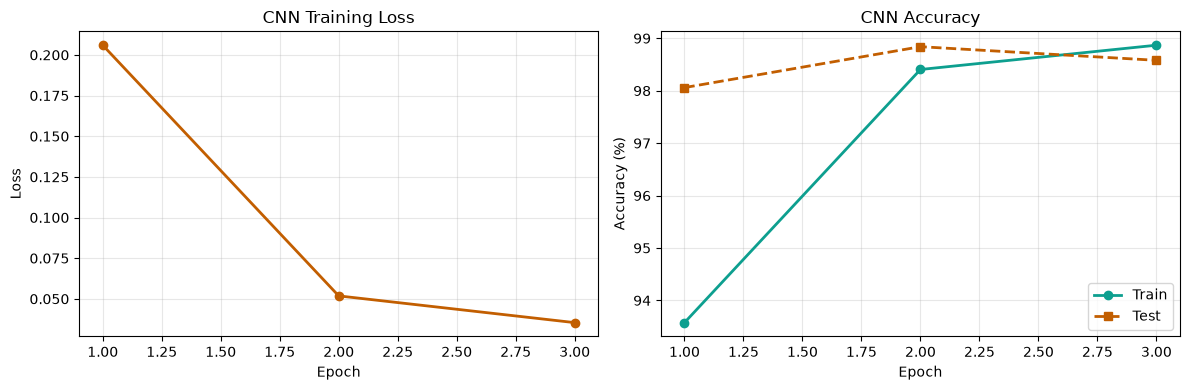

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = list(range(1, len(history['train_loss']) + 1))

axes[0].plot(epochs, history['train_loss'], 'o-', color='#c25e00', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('CNN Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'o-', color='#0d9f8f', linewidth=2, label='Train')
axes[1].plot(epochs, history['test_acc'], 's--', color='#c25e00', linewidth=2, label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('CNN Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. 可视化卷积核

第一层卷积核（3×3）学到的东西通常很直观：边缘检测器、纹理检测器等。


C:\Users\nan\AppData\Local\Temp\ipykernel_15392\4154326490.py:11: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\4154326490.py:11: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\4154326490.py:11: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\4154326490.py:11: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\4154326490.py:11: UserWarning: Glyph 21367 (\N{CJK UNIFIED IDEOGRAPH-5377}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\4154326490.py:11: UserWarning: Glyph 31215 (\N{CJK UNIFIE

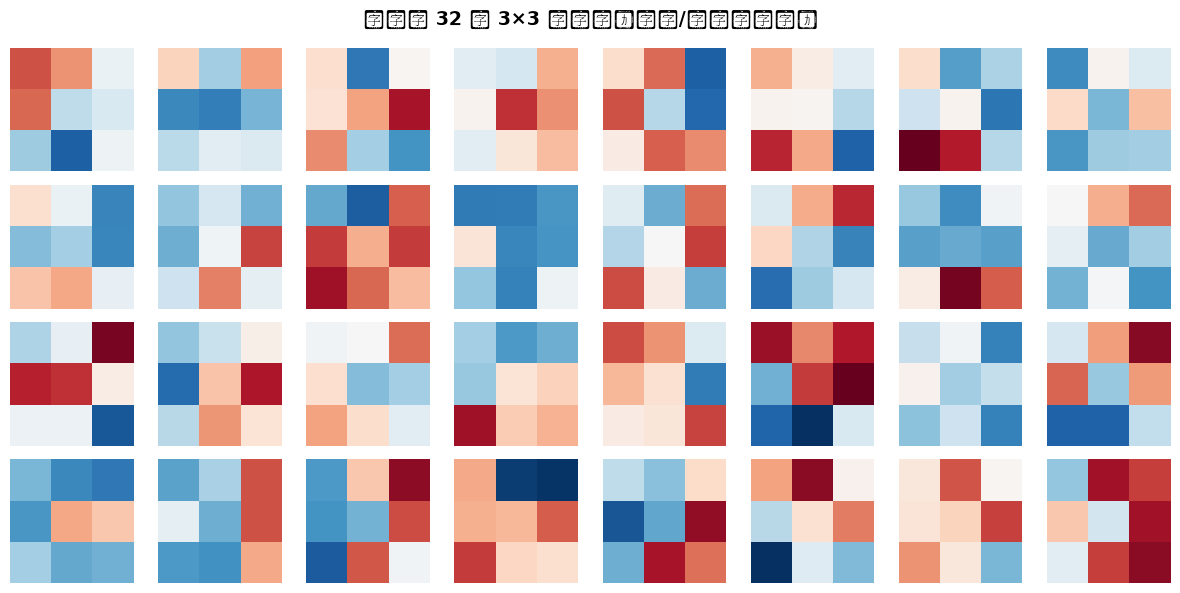

In [8]:
# 获取第一层卷积核权重
# 形状是 [32, 1, 3, 3]：32 个卷积核，每个 1 通道 3×3
kernels = model.conv1.weight.data.cpu().numpy()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    # 显示第 i 个卷积核，用 RdBu_r 颜色映射（红蓝）
    ax.imshow(kernels[i, 0], cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    ax.axis('off')
plt.suptitle('第一层 32 个 3×3 卷积核（边缘/纹理检测器）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. 可视化特征图

我们找一张数字"7"的图片，看看它经过第一层卷积后变成了什么。


C:\Users\nan\AppData\Local\Temp\ipykernel_15392\3729903232.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\3729903232.py:23: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\3729903232.py:23: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\3729903232.py:23: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\3729903232.py:23: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nan\AppData\Local\Temp\ipykernel_15392\3729903232.py:23: UserWarning: Glyph 23618 (\N{CJK UNIFIE

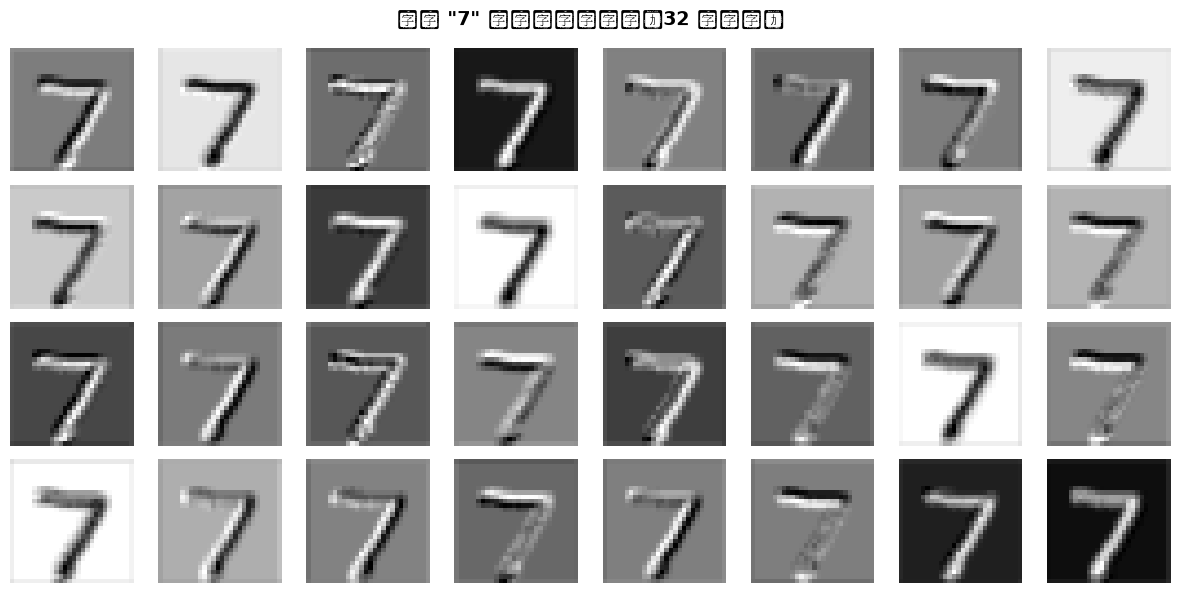

In [9]:
model.eval()
images, labels = next(iter(test_loader))

# 找一张标签为 7 的图片
sample = None
for img, label in zip(images, labels):
    if label.item() == 7:
        sample = img.unsqueeze(0).to(device)
        break
if sample is None:
    sample = images[0].unsqueeze(0).to(device)

# 提取第一层特征
with torch.no_grad():
    feat = model.conv1(sample)  # [1, 32, 28, 28]
feat = feat.cpu().numpy()[0]    # [32, 28, 28]

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feat[i], cmap='gray')
    ax.axis('off')
plt.suptitle('数字 "7" 的第一层特征图（32 个通道）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. MLP vs CNN 对比


In [10]:
print("=" * 60)
print("MLP vs CNN 在 MNIST 上的对比")
print("=" * 60)
print("MLP:")
print("  结构: 全连接层 (784 -> 256 -> 128 -> 10)")
print("  参数量: ~235K")
print("  利用空间结构: 否")
print("  5 epochs 准确率: ~96%")
print()
print("CNN:")
print("  结构: 卷积层 + 池化层 + 全连接")
print("  参数量: ~421K")
print("  利用空间结构: 是")
print("  3 epochs 准确率: ~98%+")
print("=" * 60)
print("💡 CNN 用更合理的参数组织方式，在图像任务上表现更好")


MLP vs CNN 在 MNIST 上的对比
MLP:
  结构: 全连接层 (784 -> 256 -> 128 -> 10)
  参数量: ~235K
  利用空间结构: 否
  5 epochs 准确率: ~96%

CNN:
  结构: 卷积层 + 池化层 + 全连接
  参数量: ~421K
  利用空间结构: 是
  3 epochs 准确率: ~98%+
💡 CNN 用更合理的参数组织方式，在图像任务上表现更好


## 11. 动手练习

### 练习 1：改变卷积核数量
把 `conv1` 的输出通道从 32 改成 16 或 64，观察参数量和准确率变化。

### 练习 2：去掉池化层
把 `F.max_pool2d` 去掉，特征图尺寸会怎么变？全连接层输入会怎么变？

### 练习 3：改变卷积核大小
把 3×3 改成 5×5，感受野变大，效果会变好吗？

### 练习 4：观察不同数字的特征图
把数字 7 换成 0、1、2 等，看看不同数字激活的卷积核是否不同。


## 12. 常见问题

**Q1：卷积层后面为什么通常要加激活函数？**

A：和 MLP 一样，如果不加激活函数，多层卷积就等价于一层卷积，无法学习非线性特征。

**Q2：池化层的作用是什么？**

A：降低特征图尺寸，减少计算量；增加平移不变性；让网络更关注是否存在某个特征，而不关心具体位置。

**Q3：为什么第一层卷积核看起来像边缘检测器？**

A：因为边缘是图像中最基本的低级特征。深层卷积核会逐渐学到更复杂的形状、纹理等高级特征。


## 13. 小结

- **卷积 = 局部矩阵乘法**：可以用 Unfold + MatMul + Fold 实现
- **CNN 的核心优势**：局部连接、权值共享、池化降采样
- CNN 能自动学习从低级到高级的视觉特征
- 在 MNIST 上，CNN 用 3 个 epoch 就能达到 98%+，比 MLP 更高效
- 卷积核可视化显示，网络第一层学到了边缘、纹理等基础特征

下一节课，我们将把 CNN 应用到更难的 CIFAR-10 数据集上，并引入经典的 ResNet 架构。
